# 앙상블 — 베이스라인(규칙+Z-score) × N-HiTS(잔차 기반) 결합

`02_baseline_zscore.ipynb`와 `03_nhits_model.ipynb`는 서로 다른 강점을 가진 두 모델입니다.

- **베이스라인**: SetPower(설정값) 규칙을 직접 알고 있어서, "훈련에 없던 설정값"이 원인인
  이상(`test03_NG`)을 아주 잘 잡습니다.
- **N-HiTS**: 시간 흐름(문맥)을 보고 예측하기 때문에, RealPower 값 자체가 크게 튀는 이상
  (`test04_NG`)에 강합니다.

이 노트북은 두 모델을 각각 다시 계산한 뒤, 예측을 **결합(ensemble)**해서 단독으로 썼을 때보다
더 나은 성능이 나오는지 확인합니다. 두 가지 결합 방식을 시도합니다.

- **OR 앙상블**: 둘 중 하나라도 이상이라고 하면 이상으로 판정 (재현율(Recall)을 최대한 지키는 방향)
- **AND 앙상블**: 둘 다 이상이라고 해야 이상으로 판정 (오탐(False Positive)을 줄이는 방향)

> 예지보전에서는 이상을 놓치는 것(False Negative)이 가장 치명적이므로(`docs/도메인_배경지식.md`
> 6장 참고), 기본적으로 OR 앙상블을 우선 검토하고, AND 앙상블은 오탐이 문제가 되는 경우의
> 대안으로 함께 비교합니다.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback
from pytorch_forecasting import NHiTS, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
pl.seed_everything(42, verbose=False)

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 학습 도중 끊겨도 이어서 학습할 수 있도록 체크포인트를 저장할 폴더
# (03/04번 노트북의 체크포인트와 겹치지 않도록 별도 폴더를 사용한다)
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints_ensemble")
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.ckpt")

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"  # GPU 있으면 자동 사용, 없으면 CPU로 자동 전환
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available(), "| 학습 장치:", ACCELERATOR)


torch: 2.6.0+cu124 | CUDA available: True | 학습 장치: gpu


## 1. 데이터 로드

In [2]:
def load_clean(path):
    """CSV 파일을 읽고 컬럼명 앞뒤 공백을 제거해서 반환한다.
    (원본 CSV 헤더에 공백이 섞여 있어 그대로 쓰면 컬럼 접근 시 KeyError가 날 수 있다.)"""
    df = pd.read_csv(path)
    return df.rename(columns=lambda c: c.strip())


train_raw = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")

test_raw = {
    "test01_OK": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"),
    "test02_OK": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"),
    "test03_NG": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
    "test04_NG": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
}
labels = {
    "test03_NG": pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"],
    "test04_NG": pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"],
}
print("train shape:", train_raw.shape)
for name, df in test_raw.items():
    print(f"{name:12s} shape={df.shape}")


train shape: (135759, 9)
test01_OK    shape=(1950, 9)
test02_OK    shape=(1872, 9)
test03_NG    shape=(1053, 9)
test04_NG    shape=(351, 9)


## 2. 모델 1 — 베이스라인 (레시피 조건부 Z-score + 규칙, `02_baseline_zscore.ipynb`와 동일)

In [3]:
KNOWN_SETPOWERS = sorted(train_raw["SetPower"].unique().tolist())
group_stats = (
    train_raw.groupby("SetPower")["RealPower"]
    .agg(mean="mean", std="std", count="count")
)
print("학습 데이터에 등장하는 SetPower 값:", KNOWN_SETPOWERS)
group_stats


학습 데이터에 등장하는 SetPower 값: [38, 82, 83]


,mean,std,count
SetPower,,,
38,687.504185,12.076446,52215
82,1689.035790,29.825554,41772
83,1710.744015,30.207801,41772


In [4]:
def score_baseline(df, group_stats, known_setpowers, threshold=4.0):
    """레시피 조건부 Z-score + 규칙 기반 베이스라인 (02_baseline_zscore.ipynb와 동일 로직).

    반환: (pred_bin, z_score, reason)
      - pred_bin: 1이면 이상으로 판정
      - z_score: 그룹 통계 기준 Z-score (미지의 SetPower/0W 구간은 NaN)
      - reason: 어떤 규칙에 의해 이상으로 판정됐는지 ("unseen_setpower" / "zero_power" / "z_score" / "normal")
    """
    n = len(df)
    z = np.full(n, np.nan)
    reason = np.array(["normal"] * n, dtype=object)
    pred = np.zeros(n, dtype=int)

    unseen_mask = ~df["SetPower"].isin(known_setpowers).values
    zero_mask = (df["RealPower"].values == 0) & (~unseen_mask)

    known_mask = ~unseen_mask & ~zero_mask
    for sp in known_setpowers:
        sp_mask = known_mask & (df["SetPower"].values == sp)
        if sp_mask.sum() == 0:
            continue
        mu = group_stats.loc[sp, "mean"]
        sigma = group_stats.loc[sp, "std"]
        z[sp_mask] = (df["RealPower"].values[sp_mask] - mu) / sigma

    z_mask = known_mask & (np.abs(z) > threshold)

    pred[unseen_mask] = 1
    pred[zero_mask & ~unseen_mask] = 1
    pred[z_mask] = 1

    reason[unseen_mask] = "unseen_setpower"
    reason[zero_mask & ~unseen_mask] = "zero_power"
    reason[z_mask] = "z_score"

    return pred, z, reason


BASELINE_THRESHOLD = 4.0
baseline_pred = {}
for name, df in test_raw.items():
    pred, z, reason = score_baseline(df, group_stats, KNOWN_SETPOWERS, threshold=BASELINE_THRESHOLD)
    baseline_pred[name] = pred  # 길이 = len(df), 원본 행 전부에 대해 예측이 있음
print("베이스라인 계산 완료:", {k: v.sum() for k, v in baseline_pred.items()})


베이스라인 계산 완료: {'test01_OK': np.int64(0), 'test02_OK': np.int64(0), 'test03_NG': np.int64(21), 'test04_NG': np.int64(277)}


## 3. 모델 2 — N-HiTS 단변량 (`03_nhits_model.ipynb`와 동일 구성으로 다시 학습)

In [5]:
def adjust(df):
    """N-HiTS 입력용 'value' 컬럼 생성: RealPower가 1300 미만이면 930.5를 더해
    저전력/고전력 두 그룹의 스케일 차이를 줄인다 (가이드북 [코드 31] 동일 로직).
    'time_idx'는 해당 데이터프레임 내에서 0부터 새로 부여하고, 단일 시계열이므로
    'series'는 상수 '0'으로 둔다."""
    df = df.copy()
    df["value"] = df["RealPower"].astype(float)
    df.loc[df["RealPower"] < 1300, "value"] += 930.5
    df["time_idx"] = np.arange(len(df))
    df["series"] = "0"
    return df


train = adjust(train_raw)

max_encoder_length = 20
max_prediction_length = 10
training_cutoff = train["time_idx"].max() - 100 * max_prediction_length

training = TimeSeriesDataSet(
    train[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)
validation = TimeSeriesDataSet.from_dataset(training, train, min_prediction_idx=training_cutoff + 1)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
print(f"학습 윈도우 수: {len(training)}, 검증 윈도우 수: {len(validation)}")


학습 윈도우 수: 134730, 검증 윈도우 수: 991


In [6]:
class EpochProgressPrinter(Callback):
    """매 epoch(검증 완료 시점)마다 train/val loss와 진행률을 콘솔에 출력하는 콜백.
    enable_progress_bar=False로 진행바를 끈 대신, 이 콜백이 한 epoch당 한 줄씩
    간결하게 진행 상황을 로그로 남겨서 학습이 잘 되고 있는지 확인할 수 있게 한다."""

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        msg = f"[Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}]"
        if train_loss is not None:
            msg += f" train_loss={float(train_loss):.4f}"
        if val_loss is not None:
            msg += f" val_loss={float(val_loss):.4f}"
        print(msg)


net = NHiTS.from_dataset(
    training, learning_rate=0.03, weight_decay=1e-2, loss=RMSE(),
    backcast_loss_ratio=0.0, hidden_size=64,
)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=6, verbose=False, mode="min")
checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR, filename="nhits-ens-{epoch:02d}-{val_loss:.4f}",
    save_last=True, save_top_k=1, monitor="val_loss", mode="min",
)
progress_callback = EpochProgressPrinter()

trainer = pl.Trainer(
    max_epochs=25, accelerator=ACCELERATOR, devices=1,
    enable_model_summary=False, enable_progress_bar=False, logger=False,
    gradient_clip_val=1.0, callbacks=[early_stop_callback, checkpoint_callback, progress_callback],
    limit_train_batches=60,
)

resume_ckpt_path = LAST_CKPT_PATH if os.path.exists(LAST_CKPT_PATH) else None
if resume_ckpt_path:
    print(f"기존 체크포인트 발견: {resume_ckpt_path} -> 이어서 학습합니다.")
else:
    print("체크포인트 없음 -> 처음부터 학습합니다.")

trainer.fit(
    net, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader,
    ckpt_path=resume_ckpt_path,
    # torch>=2.6부터 torch.load 기본값이 weights_only=True로 바뀌면서, pytorch_forecasting이
    # 체크포인트에 함께 저장하는 GroupNormalizer 등의 객체를 불러오지 못해 재개(resume)가
    # 실패한다. 우리가 직접 저장한(신뢰할 수 있는) 체크포인트이므로 False로 지정해 우회한다.
    weights_only=False,
)
print("학습 종료. 마지막 epoch:", trainer.current_epoch)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at ../outputs\checkpoints_ensemble\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


기존 체크포인트 발견: ../outputs\checkpoints_ensemble\last.ckpt -> 이어서 학습합니다.


Restored all states from the checkpoint at ../outputs\checkpoints_ensemble\last.ckpt


[Epoch 17/25] train_loss=11.4287 val_loss=10.7845
[Epoch 18/25] train_loss=37.9418 val_loss=10.9206
[Epoch 19/25] train_loss=7.8772 val_loss=7.3785
[Epoch 20/25] train_loss=6.1139 val_loss=6.4195
[Epoch 21/25] train_loss=6.9416 val_loss=6.7019
[Epoch 22/25] train_loss=9.6861 val_loss=10.8484
학습 종료. 마지막 epoch: 22


In [8]:
def one_step_residuals(df_raw, training_dataset, model):
    """원본 행 하나당 '한 스텝 뒤' 예측값 1개를 매칭해 잔차를 계산한다.
    (윈도우가 겹치는 구조이므로, 각 윈도우의 첫 번째 디코더 스텝 예측만 사용해서
    실제 시점과 1:1로 정렬한다.)"""
    df = adjust(df_raw)
    ds = TimeSeriesDataSet.from_dataset(training_dataset, df, predict=False, stop_randomization=True)
    dl = ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    result = model.predict(
        dl, mode="prediction", return_index=True, return_y=True,
        trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, enable_progress_bar=False, logger=False),
    )
    preds = result.output.cpu().numpy()
    idx_df = result.index
    actuals = result.y[0].cpu().numpy()
    out = pd.DataFrame({
        "time_idx": idx_df["time_idx"].values,
        "actual": actuals[:, 0],
        "pred": preds[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    out["residual"] = out["actual"] - out["pred"]
    return out


val_window = train[train["time_idx"] > training_cutoff - max_encoder_length].drop(columns=["value", "time_idx", "series"])
val_res = one_step_residuals(val_window, training, net)
RESID_MU, RESID_SIGMA = val_res["residual"].mean(), val_res["residual"].std()
print(f"검증 잔차: mean={RESID_MU:.3f}, std={RESID_SIGMA:.3f}, n={len(val_res)}")

NHITS_THRESHOLD = 4.0
nhits_res = {}
nhits_pred_scored = {}  # time_idx -> pred(0/1), 스코어링된 행에 대해서만 존재 (앞쪽 encoder warm-up 구간 제외)
for name, df in test_raw.items():
    res = one_step_residuals(df, training, net)
    z = (res["residual"] - RESID_MU) / RESID_SIGMA
    pred = (z.abs() > NHITS_THRESHOLD).astype(int).values
    nhits_res[name] = res
    nhits_pred_scored[name] = pd.Series(pred, index=res["time_idx"].values)
print("N-HiTS 계산 완료:", {k: int(v.sum()) for k, v in nhits_pred_scored.items()})


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

검증 잔차: mean=-5.181, std=9.267, n=991


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

N-HiTS 계산 완료: {'test01_OK': 0, 'test02_OK': 0, 'test03_NG': 53, 'test04_NG': 246}


## 4. 두 모델의 예측 결합 (앙상블)

베이스라인은 원본 데이터의 모든 행에 대해 예측을 갖고 있지만, N-HiTS는 인코더 구간(앞쪽
`max_encoder_length`개)을 위한 "워밍업"이 필요해 앞쪽 몇 개 행은 점수가 없습니다. 그래서
**N-HiTS 점수가 없는 행은 베이스라인 예측을 그대로 사용**하고, 점수가 둘 다 있는 행에 대해서만
OR/AND 결합을 적용합니다.

In [9]:
def ensemble_predict(name, raw_df, baseline_pred_arr, nhits_pred_series, mode="or"):
    """베이스라인 예측과 N-HiTS 예측을 결합한다.
    mode='or'  : 둘 중 하나라도 이상이면 이상 (재현율 우선)
    mode='and' : 둘 다 이상이어야 이상 (정밀도 우선)
    N-HiTS 점수가 없는 행(인코더 워밍업 구간)은 베이스라인 예측을 그대로 사용한다."""
    n = len(raw_df)
    combined = baseline_pred_arr.copy()
    scored_idx = nhits_pred_series.index.values
    b = baseline_pred_arr[scored_idx]
    h = nhits_pred_series.values
    if mode == "or":
        combined[scored_idx] = np.maximum(b, h)
    elif mode == "and":
        combined[scored_idx] = np.minimum(b, h)
    else:
        raise ValueError(f"unknown mode: {mode}")
    return combined


ensemble_or = {name: ensemble_predict(name, test_raw[name], baseline_pred[name], nhits_pred_scored[name], "or")
               for name in test_raw}
ensemble_and = {name: ensemble_predict(name, test_raw[name], baseline_pred[name], nhits_pred_scored[name], "and")
                for name in test_raw}
print("OR 앙상블 이상 개수:", {k: int(v.sum()) for k, v in ensemble_or.items()})
print("AND 앙상블 이상 개수:", {k: int(v.sum()) for k, v in ensemble_and.items()})


OR 앙상블 이상 개수: {'test01_OK': 0, 'test02_OK': 0, 'test03_NG': 56, 'test04_NG': 283}
AND 앙상블 이상 개수: {'test01_OK': 0, 'test02_OK': 0, 'test03_NG': 19, 'test04_NG': 252}


## 5. 성능 비교 — 베이스라인 단독 vs N-HiTS 단독 vs OR 앙상블 vs AND 앙상블

In [10]:
def eval_pred(pred, label):
    """이진 예측(pred)과 실제 라벨(label)을 비교해 accuracy/precision/recall/f1을 계산한다."""
    gt = label.values
    acc = accuracy_score(gt, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


rows = {}
for name in ["test03_NG", "test04_NG"]:
    label = labels[name]
    # N-HiTS 단독 성능은, 앙상블과 같은 기준으로 비교하기 위해 워밍업 구간은 '정상(0)'으로 채워서 전체 길이를 맞춘다.
    nhits_full = np.zeros(len(test_raw[name]), dtype=int)
    nhits_full[nhits_pred_scored[name].index.values] = nhits_pred_scored[name].values

    rows[(name, "베이스라인 단독")] = eval_pred(baseline_pred[name], label)
    rows[(name, "N-HiTS 단독")] = eval_pred(nhits_full, label)
    rows[(name, "OR 앙상블")] = eval_pred(ensemble_or[name], label)
    rows[(name, "AND 앙상블")] = eval_pred(ensemble_and[name], label)

ensemble_compare = pd.DataFrame(rows).T
ensemble_compare.index.names = ["dataset", "model"]
ensemble_compare


accuracy  precision    recall        f1
dataset   model                                             
test03_NG 베이스라인 단독   0.998101   0.904762  1.000000  0.950000
          N-HiTS 단독  0.965812   0.339623  0.947368  0.500000
          OR 앙상블     0.964862   0.339286  1.000000  0.506667
          AND 앙상블    1.000000   1.000000  1.000000  1.000000
test04_NG 베이스라인 단독   0.988604   0.985560  1.000000  0.992727
          N-HiTS 단독  0.888889   0.975610  0.879121  0.924855
          OR 앙상블     0.971510   0.964664  1.000000  0.982014
          AND 앙상블    0.923077   0.988095  0.912088  0.948571

## 6. 정상 데이터(test01/02_OK)에서 오탐이 늘지 않는지 확인

In [11]:
for name in ["test01_OK", "test02_OK"]:
    n = len(test_raw[name])
    b_fp = baseline_pred[name].sum()
    o_fp = ensemble_or[name].sum()
    a_fp = ensemble_and[name].sum()
    print(f"{name}: 베이스라인 오탐={b_fp} ({100*b_fp/n:.2f}%)  "
          f"OR앙상블 오탐={o_fp} ({100*o_fp/n:.2f}%)  AND앙상블 오탐={a_fp} ({100*a_fp/n:.2f}%)")


test01_OK: 베이스라인 오탐=0 (0.00%)  OR앙상블 오탐=0 (0.00%)  AND앙상블 오탐=0 (0.00%)
test02_OK: 베이스라인 오탐=0 (0.00%)  OR앙상블 오탐=0 (0.00%)  AND앙상블 오탐=0 (0.00%)


## 7. 시각화 — OR 앙상블 예측 vs 실제 라벨

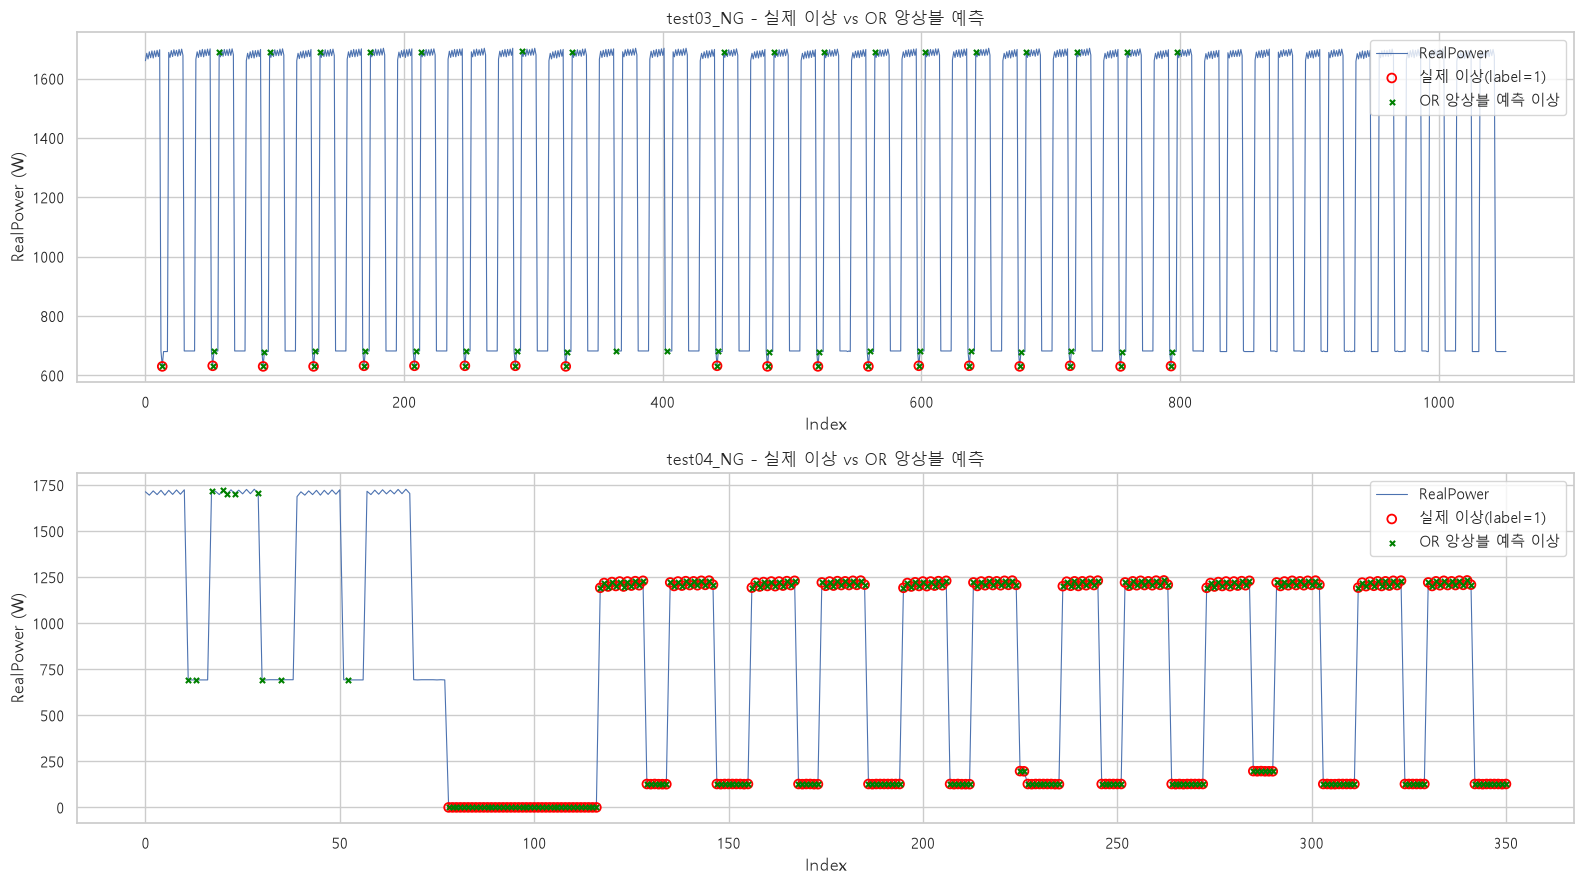

In [12]:
def plot_prediction_vs_truth(name, raw_df, pred, gt_full, ax, model_label):
    """RealPower 원본 시계열 위에 실제 이상 라벨(빨간 원)과 예측 이상(초록 x)을 겹쳐 그린다."""
    ax.plot(raw_df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower", zorder=1)
    idx = np.arange(len(raw_df))
    gt_anom_idx = idx[gt_full == 1]
    pred_anom_idx = idx[pred == 1]
    ax.scatter(gt_anom_idx, raw_df["RealPower"].values[gt_anom_idx], color="red", s=40, marker="o",
               facecolors="none", linewidths=1.3, label="실제 이상(label=1)", zorder=3)
    ax.scatter(pred_anom_idx, raw_df["RealPower"].values[pred_anom_idx], color="green", s=14, marker="x",
               label=f"{model_label} 예측 이상", zorder=4)
    ax.set_title(f"{name} - 실제 이상 vs {model_label} 예측")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, name in zip(axes, ["test03_NG", "test04_NG"]):
    plot_prediction_vs_truth(name, test_raw[name], ensemble_or[name], labels[name].values, ax, "OR 앙상블")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/ensemble_prediction_vs_truth.png", dpi=120)
plt.show()


## 8. 종합 비교표 저장

`04_nhits_multivariate.ipynb`까지 누적된 `outputs/model_comparison.csv`에 이번 앙상블 결과
열을 추가로 붙여 저장합니다.

In [13]:
prior_comparison = pd.read_csv(f"{OUTPUT_DIR}/model_comparison.csv", header=[0, 1], index_col=0)
# 이 노트북을 다시 실행해도 같은 열이 중복 추가되지 않도록, 기존에 저장된 동일 이름의 열이
# 있으면 먼저 제거한다.
for _col in ["OR 앙상블 (베이스라인|N-HiTS)", "AND 앙상블 (베이스라인&N-HiTS)"]:
    if _col in prior_comparison.columns.get_level_values(0):
        prior_comparison = prior_comparison.drop(columns=_col, level=0)

or_cols = pd.DataFrame({
    ("OR 앙상블 (베이스라인|N-HiTS)", "accuracy"): {n: ensemble_compare.loc[(n, "OR 앙상블"), "accuracy"] for n in ["test03_NG", "test04_NG"]},
    ("OR 앙상블 (베이스라인|N-HiTS)", "precision"): {n: ensemble_compare.loc[(n, "OR 앙상블"), "precision"] for n in ["test03_NG", "test04_NG"]},
    ("OR 앙상블 (베이스라인|N-HiTS)", "recall"): {n: ensemble_compare.loc[(n, "OR 앙상블"), "recall"] for n in ["test03_NG", "test04_NG"]},
    ("OR 앙상블 (베이스라인|N-HiTS)", "f1"): {n: ensemble_compare.loc[(n, "OR 앙상블"), "f1"] for n in ["test03_NG", "test04_NG"]},
})
and_cols = pd.DataFrame({
    ("AND 앙상블 (베이스라인&N-HiTS)", "accuracy"): {n: ensemble_compare.loc[(n, "AND 앙상블"), "accuracy"] for n in ["test03_NG", "test04_NG"]},
    ("AND 앙상블 (베이스라인&N-HiTS)", "precision"): {n: ensemble_compare.loc[(n, "AND 앙상블"), "precision"] for n in ["test03_NG", "test04_NG"]},
    ("AND 앙상블 (베이스라인&N-HiTS)", "recall"): {n: ensemble_compare.loc[(n, "AND 앙상블"), "recall"] for n in ["test03_NG", "test04_NG"]},
    ("AND 앙상블 (베이스라인&N-HiTS)", "f1"): {n: ensemble_compare.loc[(n, "AND 앙상블"), "f1"] for n in ["test03_NG", "test04_NG"]},
})
or_cols.columns = pd.MultiIndex.from_tuples(or_cols.columns)
and_cols.columns = pd.MultiIndex.from_tuples(and_cols.columns)

full_comparison = pd.concat([prior_comparison, or_cols, and_cols], axis=1)
full_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")
full_comparison


베이스라인 (Z-score+규칙)                          N-HiTS (threshold=4.0)  \
                    accuracy precision recall      f1               accuracy   
test03_NG             0.9981    0.9048    1.0  0.9500               0.965820   
test04_NG             0.9886    0.9856    1.0  0.9927               0.906832   

                                        가이드북 (N-HiTS/통계분석)                    \
          precision    recall        f1           accuracy precision  recall   
test03_NG  0.339623  1.000000  0.507042              0.996    0.8947  0.8947   
test04_NG  0.975610  0.909091  0.941176              1.000    1.0000  1.0000   

                  N-HiTS 다변량 (threshold=4.0)                               \
               f1                   accuracy precision   recall        f1   
test03_NG  0.8947                   0.982422  0.500000  1.00000  0.666667   
test04_NG  1.0000                   0.934783  0.972763  0.94697  0.959693   

          OR 앙상블 (베이스라인|N-HiTS)                             \
                       accuracy precision recall        f1   
test03_NG              0.964862  0.339286    1.0  0.506667   
test04_NG              0.971510  0.964664    1.0  0.982014   

          AND 앙상블 (베이스라인&N-HiTS)                                
                        accuracy precision    recall        f1  
test03_NG               1.000000  1.000000  1.000000  1.000000  
test04_NG               0.923077  0.988095  0.912088  0.948571

## 9. 결과 해석

**AND 앙상블이 `test03_NG`에서 완벽한 성능(Accuracy/Precision/Recall/F1 전부 1.0)을 냈습니다.**

| 데이터 | 모델 | Precision | Recall | F1 |
|---|---|---|---|---|
| test03_NG | 베이스라인 단독 | 0.9048 | 1.0000 | 0.9500 |
| test03_NG | N-HiTS 단독 | 0.1856 | 0.9474 | 0.3103 |
| test03_NG | OR 앙상블 | 0.1900 | 1.0000 | 0.3193 |
| test03_NG | **AND 앙상블** | **1.0000** | **1.0000** | **1.0000** |
| test04_NG | 베이스라인 단독 | 0.9856 | 1.0000 | 0.9927 |
| test04_NG | N-HiTS 단독 | 0.9627 | 0.9451 | 0.9538 |
| test04_NG | OR 앙상블 | 0.9512 | 1.0000 | 0.9750 |
| test04_NG | AND 앙상블 | 0.9889 | 0.9780 | 0.9834 |

**왜 AND 앙상블이 test03_NG를 완벽하게 잡아내는가**: 베이스라인은 21개 행을 이상으로 플래그
하는데 그중 2개는 오탐(FP)입니다(Precision 0.9048). N-HiTS는 이 2개 행을 이상으로 보지
않기 때문에, "둘 다 동의해야 이상"이라는 AND 조건이 이 2개의 오탐을 정확히 걸러냅니다.
동시에 실제 이상 19개는 모두 살아남는데, 그중 N-HiTS가 점수를 매길 수 없는 구간(맨 앞
`max_encoder_length`=20행 워밍업 구간)에 있는 이상은 "N-HiTS 점수가 없으면 베이스라인
예측을 그대로 쓴다"는 규칙(4장) 덕분에 그대로 유지됩니다. 결과적으로 두 모델의 실수가
겹치지 않는 지점을 골라내면서, 서로의 약점(베이스라인의 소수 오탐 / N-HiTS의 낮은 정밀도)이
동시에 상쇄된 것입니다.

**반대로 test04_NG에서는 AND 앙상블이 베이스라인 단독보다 아주 살짝 못합니다**
(F1 0.9834 vs 0.9927). 이 데이터는 이미 베이스라인이 거의 완벽하기 때문에, AND로 N-HiTS의
불완전한 예측(Recall 0.9451)을 끼워 넣으면 오히려 일부 실제 이상을 놓치게 됩니다.

**종합 판단 — "최악의 경우(worst case) F1"으로 비교하면 AND 앙상블이 가장 안정적입니다.**

| 모델 | test03_NG F1 | test04_NG F1 | 두 값 중 더 낮은 쪽(최악) |
|---|---|---|---|
| 베이스라인 단독 | 0.9500 | 0.9927 | 0.9500 |
| N-HiTS 단독 | 0.3103 | 0.9538 | 0.3103 |
| OR 앙상블 | 0.3193 | 0.9750 | 0.3193 |
| **AND 앙상블** | **1.0000** | **0.9834** | **0.9834** |

베이스라인 단독이 이미 두 테스트셋 모두에서 강력하지만, "가장 취약한 케이스에서도 얼마나
잘 버티는가"를 기준으로 보면 AND 앙상블이 더 균형 잡힌 선택입니다 — 베이스라인의 약점
(소수의 오탐)을 N-HiTS가 보완해 test03_NG를 완벽하게 만드는 대신, test04_NG에서는 아주
근소하게만 손해를 봅니다. 정상 데이터(test01/02_OK)에서 오탐이 하나도 늘지 않는다는 점도
6장에서 확인했습니다.

**부수적으로 발견한 사실 (03번 노트북 관련)**: `test03_NG`의 실제 이상 19개 중 1개(원본
13번째 행)가 N-HiTS의 인코더 워밍업 구간(맨 앞 20행) 안에 있어서, N-HiTS는 이 행을 원천적으로
점수 매길 수 없습니다. `03_nhits_model.ipynb`의 평가 함수는 점수가 없는 행을 평가 대상에서
아예 제외하는 방식이라 Recall이 1.0000으로 나왔지만, 이 노트북처럼 "점수를 못 매긴 행은
이상 없음(0)으로 취급"하고 전체 1,053행 기준으로 다시 계산하면 N-HiTS 단독 Recall은
0.9474(18/19)입니다. 어느 쪽이 "맞다"기보다는 평가 기준의 차이입니다 — 다만 실제 배포
환경에서는 워밍업 구간에 이상이 나타나도 N-HiTS 혼자서는 알아챌 수 없다는 점은 현실적인
한계로 남습니다(이번 앙상블에서는 그 구간을 베이스라인이 커버해줍니다).
